In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from obspy import read
from tensorflow import keras
from tensorflow.keras import layers, ops
import random
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder

seed = 42

# Environment-level
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# Library-level
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Config
input_length = 3000

# Path split
splits_root = r"E:\Skripsi\DEC\dataset\ae-supervised-dataset\splits-baru" 
train_manifest = os.path.join(splits_root, "train.csv")
test_manifest  = os.path.join(splits_root, "test.csv")
val_manifest   = os.path.join(splits_root, "val.csv")


In [2]:
def load_waveform(path):
    st = read(path)
    tr = st[0].data.astype(np.float32)
    return tr

def load_dataset(manifest_csv):
    df = pd.read_csv(manifest_csv)
    X = [load_waveform(p) for p in df["path"]]
    X = np.array(X)
    X = np.expand_dims(X, -1)   # shape (N, 3001, 1)
    return X, df["label"].values


In [3]:
from sklearn.model_selection import train_test_split

X_train, y_train = load_dataset(train_manifest)
X_test, y_test   = load_dataset(test_manifest)
X_val, y_val     = load_dataset(val_manifest)

print("Train full shape:", X_train.shape)
print("Train shape:", X_train.shape)
print("val shape:", X_val.shape)
print("Test shape :", X_test.shape)

Train full shape: (1796, 3000, 1)
Train shape: (1796, 3000, 1)
val shape: (450, 3000, 1)
Test shape : (562, 3000, 1)


In [4]:
def check_normalization(X):
    X_flat = X.reshape(X.shape[0], -1)
    global_mean = X_flat.mean()
    global_std = X_flat.std()
    print(f"Global mean: {global_mean:.5f}")
    print(f"Global std : {global_std:.5f}")
    if abs(global_mean) < 0.05 and 0.5 < global_std < 1.5:
        print(" Data looks normalized globally.")
    else:
        print("  Data may not be properly normalized.")

# Run the check
check_normalization(X_train)
check_normalization(X_val)
check_normalization(X_test)


Global mean: -0.00002
Global std : 1.11505
 Data looks normalized globally.
Global mean: -0.00029
Global std : 1.12368
 Data looks normalized globally.
Global mean: -0.00021
Global std : 1.11810
 Data looks normalized globally.


In [5]:
def class_distribution(labels, name):
    unique, counts = np.unique(labels, return_counts=True)
    dist = pd.DataFrame({
        "class": unique,
        "count": counts,
        "percentage": (counts / counts.sum() * 100).round(2)
    })
    print(f"\n{name} distribution:")
    print(dist.to_string(index=False))

class_distribution(y_train, "Train")
class_distribution(y_val, "Validation")
class_distribution(y_test, "Test")


Train distribution:
   class  count  percentage
      MP    915       50.95
ROCKFALL    800       44.54
     VTB     81        4.51

Validation distribution:
   class  count  percentage
      MP    229       50.89
ROCKFALL    201       44.67
     VTB     20        4.44

Test distribution:
   class  count  percentage
      MP    286       50.89
ROCKFALL    251       44.66
     VTB     25        4.45


In [6]:
import joblib

le = LabelEncoder()

le.fit(y_train)

y_train = le.transform(y_train)
y_val   = le.transform(y_val)
y_test  = le.transform(y_test)

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
joblib.dump(le, "label_encoder.save")
print("Label encoder saved as 'label_encoder.save'")

Label mapping: {'MP': np.int64(0), 'ROCKFALL': np.int64(1), 'VTB': np.int64(2)}
Label encoder saved as 'label_encoder.save'


In [7]:
def build_autoencoder(input_length, latent_dim):
    inp = keras.Input(shape=(input_length, 1))

    # === Encoder ===
    x = layers.Conv1D(16, 7, activation='relu', padding='same')(inp)
    x = layers.MaxPooling1D(2, padding='same')(x)   # 3000 → ~1500
    x = layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2, padding='same')(x)   # ~1500 → ~750
    x = layers.Conv1D(64, 7, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2, padding='same')(x)   # ~750 → ~375

    # Latent representation
    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, activity_regularizer=keras.regularizers.L1(1e-5), name='latent')(x)

    # === Decoder ===
    # Map latent vector back to the same spatial shape
    x = layers.Dense((input_length // 8) * 64, activation='relu')(latent)
    x = layers.Reshape((input_length // 8, 64))(x)

    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(64, 7, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(32, 7, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(16, 7, activation='relu', padding='same')(x)
    out = layers.Conv1D(1, 1, activation='linear', padding='same')(x)

    model = keras.Model(inp, out, name='CAE')
    feature_model = keras.Model(inp, latent, name='Encoder')

    return model, feature_model


In [8]:
model, feature_model = build_autoencoder(input_length, latent_dim=64)
model.summary()
feature_model.summary()

Model: "CAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3000, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 3000, 16)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1500, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1500, 32)       │         3,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 750, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 750, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 375, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 24000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 64)             │     1,536,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24000)          │     1,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 375, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 750, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 750, 64)        │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 1500, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 1500, 32)       │        14,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_2 (UpSampling1D)  │ (None, 3000, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 3000, 16)       │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 3000, 1)        │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,160,929 (12.06 MB)

 Trainable params: 3,160,929 (12.06 MB)

 Non-trainable params: 0 (0.00 B)

Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3000, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 3000, 16)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1500, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1500, 32)       │         3,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 750, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 750, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 375, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 24000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 64)             │     1,536,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,554,208 (5.93 MB)

 Trainable params: 1,554,208 (5.93 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
def spectral_loss(y_true, y_pred):
    # Hapus dim channel (N, 3001, 1) -> (N, 3001)
    y_true = tf.squeeze(y_true, -1)
    y_pred = tf.squeeze(y_pred, -1)
    
    # Short-Time Fourier Transform
    stft_true = tf.abs(tf.signal.stft(y_true, frame_length=256, frame_step=64))
    stft_pred = tf.abs(tf.signal.stft(y_pred, frame_length=256, frame_step=64))
    
    # MSE pada magnitude spektrum
    return tf.reduce_mean(tf.square(stft_true - stft_pred))

def combined_loss(y_true, y_pred):
    # Time-domain MSE
    time_loss = tf.reduce_mean(tf.square(y_true - y_pred))
    # Spectral MSE
    spec = spectral_loss(y_true, y_pred)
    # Gabungan
    return time_loss + spec * 0.2 # β = 0.2 (bisa coba 0.1, 0.5)


In [10]:
model.compile(optimizer=keras.optimizers.Adam(1e-4), loss=combined_loss)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-5
    ),
]

history = model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    shuffle=True,
)

feature_model.save("Encoder_XGboost_Sloss.keras")
model.save("model_XGboost_Sloss.keras")


Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 195ms/step - loss: 18.5650 - val_loss: 13.9594 - learning_rate: 1.0000e-04
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 186ms/step - loss: 13.2490 - val_loss: 13.0469 - learning_rate: 1.0000e-04
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 192ms/step - loss: 12.5684 - val_loss: 12.2008 - learning_rate: 1.0000e-04
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 189ms/step - loss: 11.3484 - val_loss: 10.7628 - learning_rate: 1.0000e-04
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 189ms/step - loss: 10.3257 - val_loss: 10.0962 - learning_rate: 1.0000e-04
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 189ms/step - loss: 9.8255 - val_loss: 9.7415 - learning_rate: 1.0000e-04
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 193ms/step - loss: 9.5152 - val_loss: 9.4595 - learning_rate: 1.0000e-04
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 192ms/step - loss: 9.2130 - val_loss: 9.1772 - learning_rate: 1.0000e-04
Epoch 9/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 188ms/step - loss: 8.9683 - val_loss:

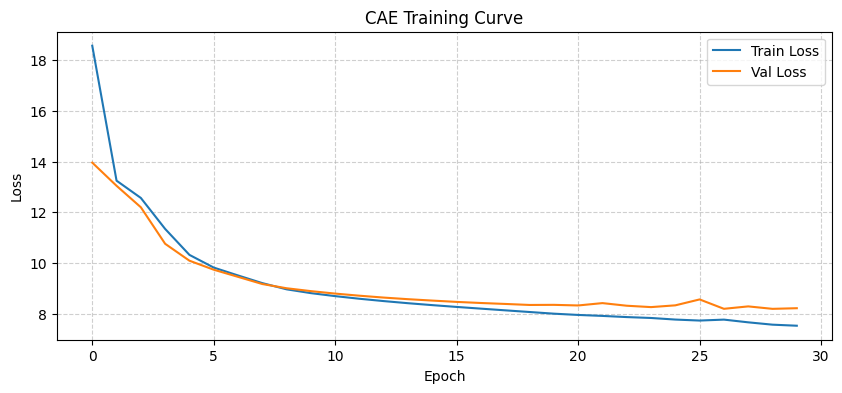

In [11]:
plt.figure(figsize=(10,4))
plt.grid(True, linestyle='--', alpha=0.6)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("CAE Training Curve")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


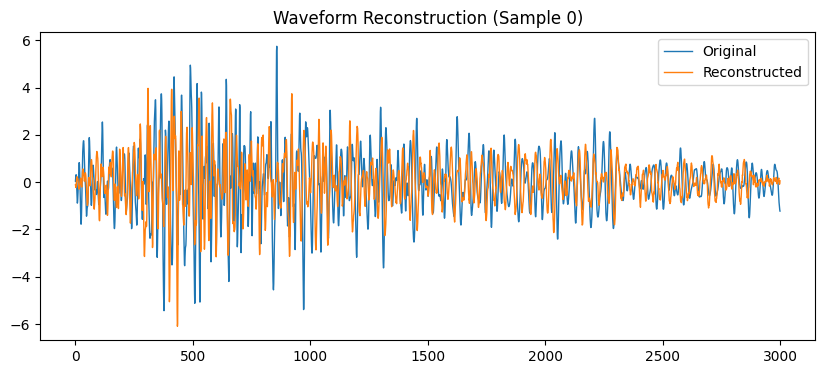

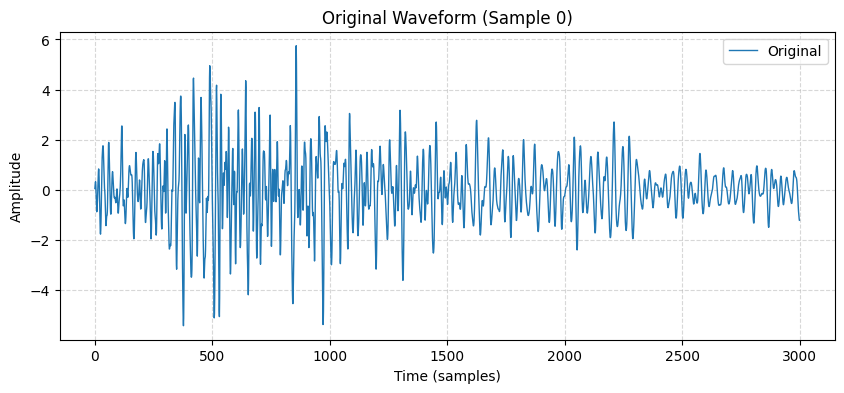

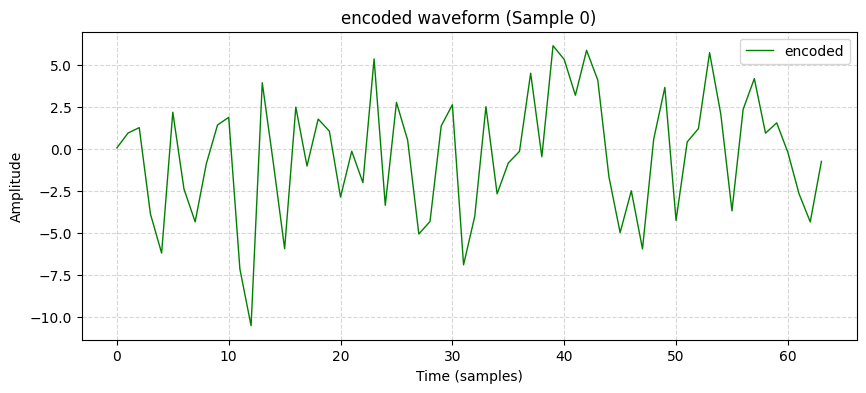

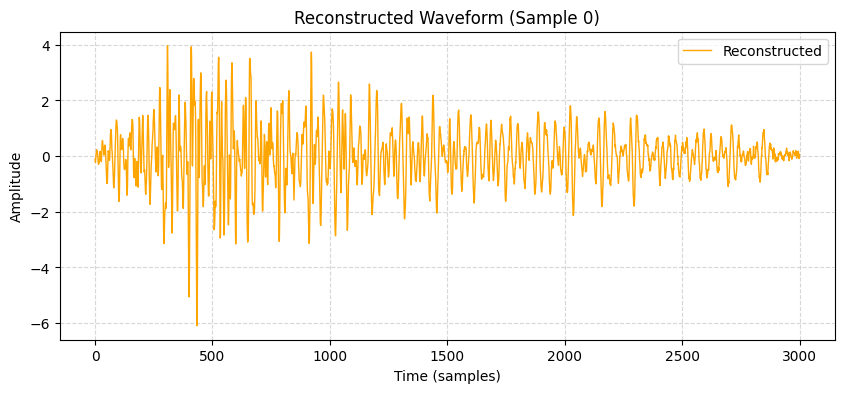

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


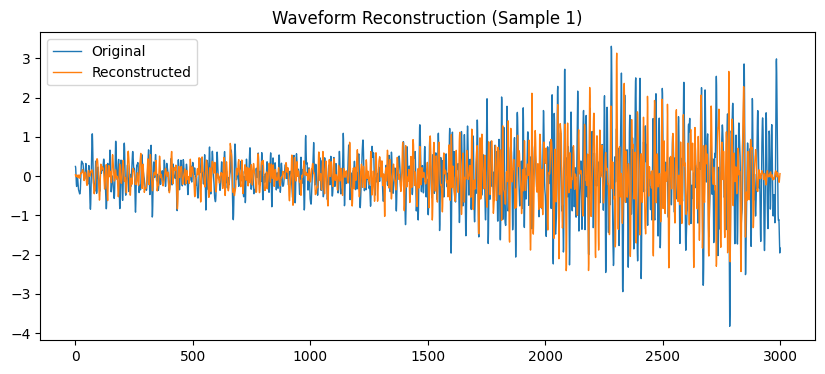

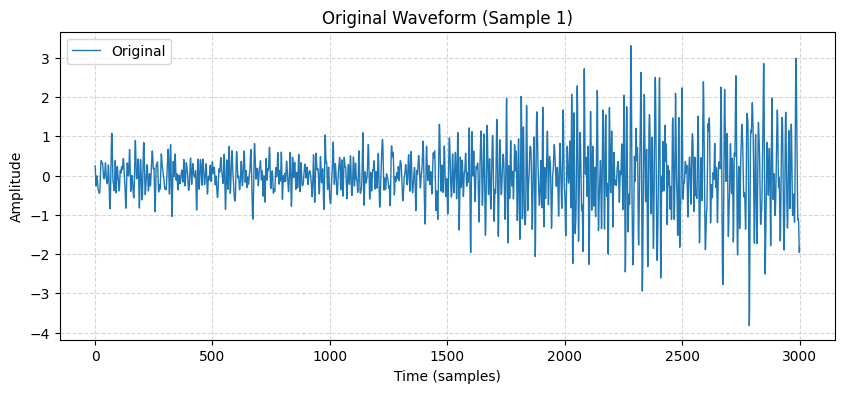

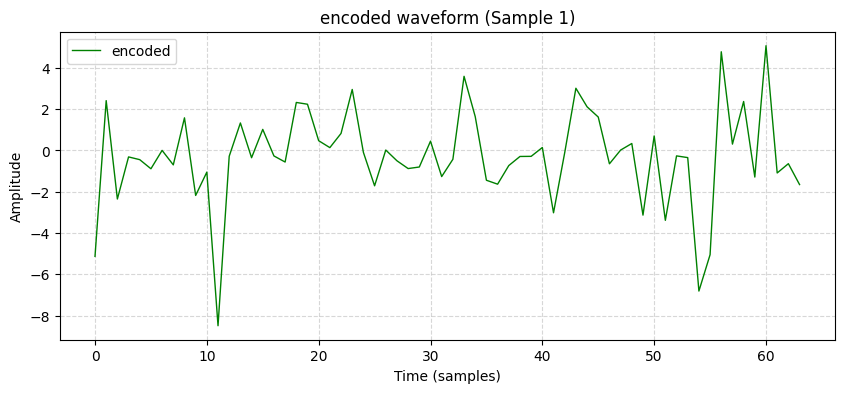

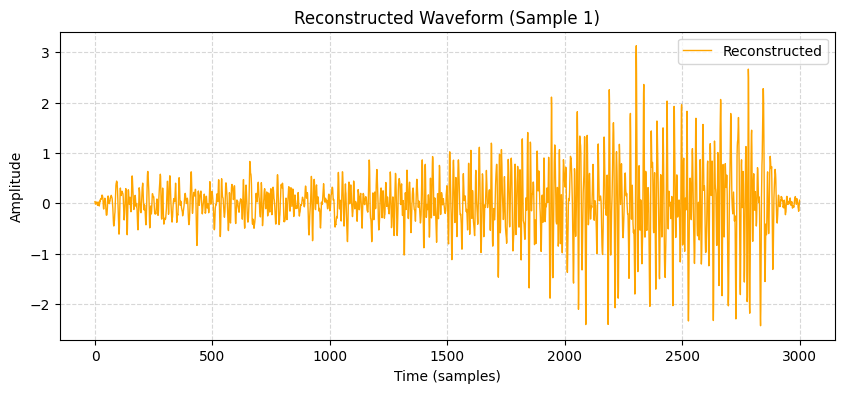

In [12]:
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model



for i in range(2):  
    sample = X_test[i:i+1]
    reconstructed = model.predict(sample)
    encoded = feature_model.predict(sample)

    plt.figure(figsize=(10,4))
    plt.plot(sample[0], label='Original', linewidth=1)
    plt.plot(reconstructed[0], label='Reconstructed', linewidth=1)
    plt.legend()
    plt.title(f"Waveform Reconstruction (Sample {i})")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(sample[0], label='Original', linewidth=1)
    plt.title(f"Original Waveform (Sample {i})")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(encoded[0], label='encoded', linewidth=1, color='green')
    plt.title(f"encoded waveform (Sample {i})")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

    # Plot reconstructed
    plt.figure(figsize=(10, 4))
    plt.plot(reconstructed[0], label='Reconstructed', linewidth=1, color='orange')
    plt.title(f"Reconstructed Waveform (Sample {i})")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()


In [13]:
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import load_model

feature_model = load_model("Encoder_XGboost_Sloss.keras")

features_train = feature_model.predict(X_train, batch_size=64)
features_val  = feature_model.predict(X_val, batch_size=64)
features_test  = feature_model.predict(X_test, batch_size=64)




29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [22]:
def check_normalization(X):
    X_flat = X.reshape(X.shape[0], -1)
    global_mean = X_flat.mean()
    global_std = X_flat.std()
    print(f"Global mean: {global_mean:.5f}")
    print(f"Global std : {global_std:.5f}")
    if abs(global_mean) < 0.05 and 0.5 < global_std < 1.5:
        print(" Data looks normalized globally.")
    else:
        print("  Data may not be properly normalized.")


# Run the check
check_normalization(features_train)
check_normalization(features_val)
check_normalization(features_test)


Global mean: -0.29895
Global std : 3.18990
  Data may not be properly normalized.
Global mean: -0.31541
Global std : 3.17030
  Data may not be properly normalized.
Global mean: -0.30191
Global std : 3.17613
  Data may not be properly normalized.


In [23]:
scaler = StandardScaler()
features_train = scaler.fit_transform(features_train)
features_val   = scaler.transform(features_val)
features_test  = scaler.transform(features_test)

print(features_train.shape)
joblib.dump(scaler, "Sloss_scaler.save")



(1796, 64)


['Sloss_scaler.save']

In [24]:
# Run the check
check_normalization(features_train)
check_normalization(features_val)
check_normalization(features_test)


Global mean: 0.00000
Global std : 1.00000
 Data looks normalized globally.
Global mean: -0.00558
Global std : 0.97472
 Data looks normalized globally.
Global mean: -0.00068
Global std : 0.98414
 Data looks normalized globally.


In [25]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    use_label_encoder=False
)

eval_set = [(features_train, y_train), (features_val, y_val)]
clf.fit(
    features_train, y_train,
    eval_set=eval_set,
    verbose=1,
)

clf.save_model("Sloss_XGboost.json")


[0]	validation_0-mlogloss:0.96954	validation_1-mlogloss:0.97043
[1]	validation_0-mlogloss:0.85939	validation_1-mlogloss:0.86300


[2]	validation_0-mlogloss:0.76752	validation_1-mlogloss:0.77361
[3]	validation_0-mlogloss:0.68895	validation_1-mlogloss:0.69641
[4]	validation_0-mlogloss:0.61959	validation_1-mlogloss:0.62876
[5]	validation_0-mlogloss:0.55969	validation_1-mlogloss:0.57080
[6]	validation_0-mlogloss:0.50765	validation_1-mlogloss:0.52037
[7]	validation_0-mlogloss:0.46097	validation_1-mlogloss:0.47653
[8]	validation_0-mlogloss:0.42028	validation_1-mlogloss:0.43783
[9]	validation_0-mlogloss:0.38372	validation_1-mlogloss:0.40288
[10]	validation_0-mlogloss:0.35079	validation_1-mlogloss:0.37210
[11]	validation_0-mlogloss:0.32171	validation_1-mlogloss:0.34440
[12]	validation_0-mlogloss:0.29457	validation_1-mlogloss:0.31999


e:\Skripsi\DEC\envTA\lib\site-packages\xgboost\training.py:183: UserWarning: [09:34:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[13]	validation_0-mlogloss:0.27078	validation_1-mlogloss:0.29858
[14]	validation_0-mlogloss:0.24961	validation_1-mlogloss:0.27870
[15]	validation_0-mlogloss:0.22998	validation_1-mlogloss:0.26144
[16]	validation_0-mlogloss:0.21242	validation_1-mlogloss:0.24637
[17]	validation_0-mlogloss:0.19644	validation_1-mlogloss:0.23186
[18]	validation_0-mlogloss:0.18200	validation_1-mlogloss:0.21991
[19]	validation_0-mlogloss:0.16818	validation_1-mlogloss:0.20855
[20]	validation_0-mlogloss:0.15598	validation_1-mlogloss:0.19865
[21]	validation_0-mlogloss:0.14495	validation_1-mlogloss:0.19030
[22]	validation_0-mlogloss:0.13466	validation_1-mlogloss:0.18242
[23]	validation_0-mlogloss:0.12549	validation_1-mlogloss:0.17503
[24]	validation_0-mlogloss:0.11683	validation_1-mlogloss:0.16842
[25]	validation_0-mlogloss:0.10865	validation_1-mlogloss:0.16225
[26]	validation_0-mlogloss:0.10114	validation_1-mlogloss:0.15724
[27]	validation_0-mlogloss:0.09414	validation_1-mlogloss:0.15242
[28]	validation_0-mloglos

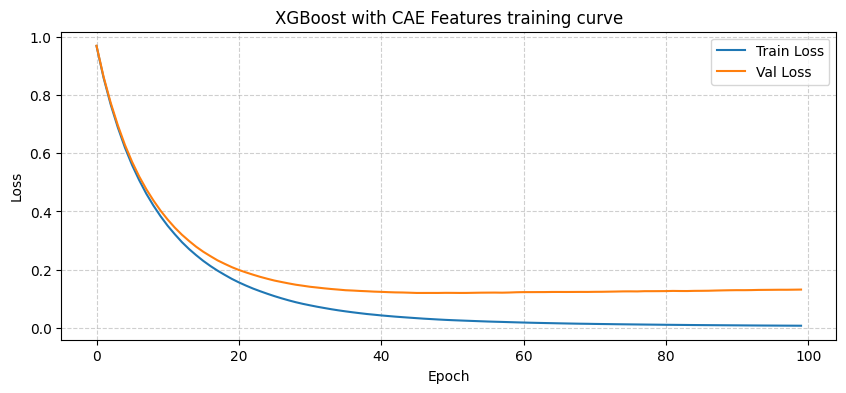

In [26]:
results = clf.evals_result()
train_loss = results['validation_0']['mlogloss']
val_loss = results['validation_1']['mlogloss']
plt.figure(figsize=(10,4))
plt.grid(True, linestyle='--', alpha=0.6)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('XGBoost with CAE Features training curve')
plt.legend()
plt.show()


              precision    recall  f1-score   support

           0     0.9693    0.9930    0.9810       286
           1     0.9919    0.9801    0.9860       251
           2     1.0000    0.8400    0.9130        25

    accuracy                         0.9804       562
   macro avg     0.9871    0.9377    0.9600       562
weighted avg     0.9808    0.9804    0.9802       562



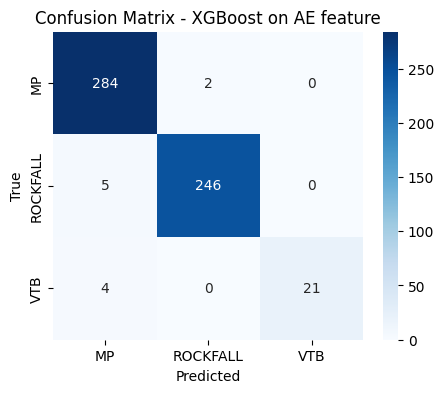

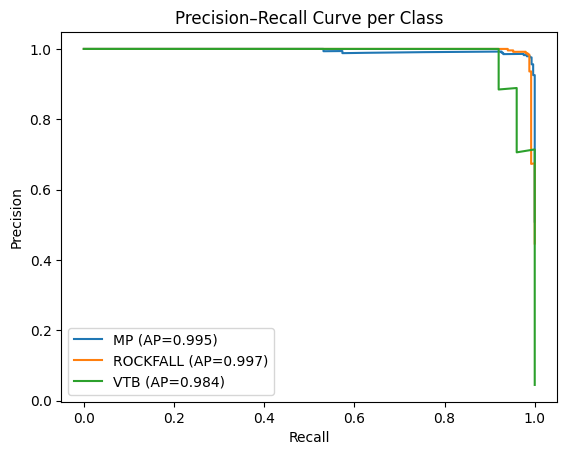

In [27]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

y_pred = clf.predict(features_test)
print(classification_report(y_test, y_pred, digits=4))

y_score = clf.predict_proba(features_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - XGBoost on AE feature")
plt.show()


for i, cls in enumerate(le.classes_):
    precision, recall, _ = precision_recall_curve(y_test == i, y_score[:, i])
    ap = average_precision_score(y_test == i, y_score[:, i])
    plt.plot(recall, precision, label=f"{cls} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve per Class")
plt.legend()
plt.show()

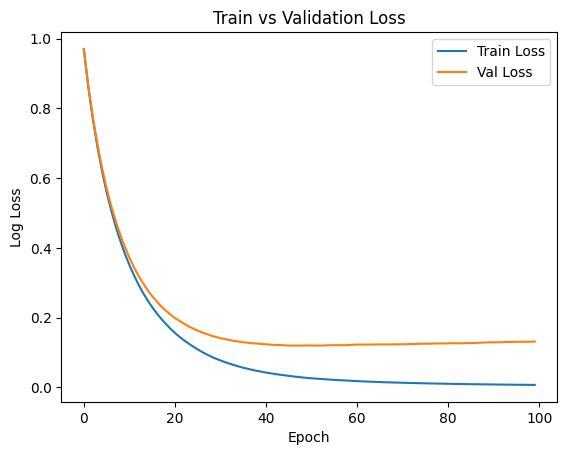

In [28]:
results = clf.evals_result()
train_loss = results['validation_0']['mlogloss']
val_loss = results['validation_1']['mlogloss']

plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.show()


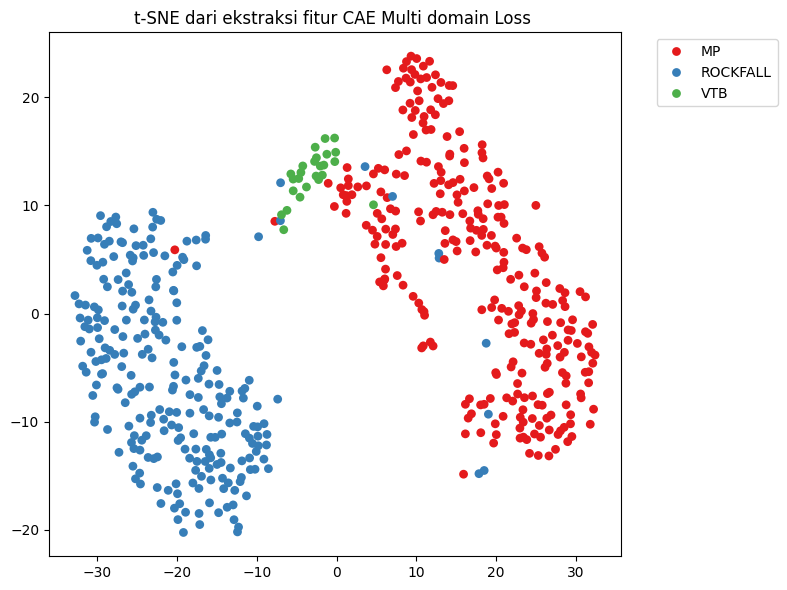

Total misclassified: 11
Example indices: [ 25  88 136 204 288 391 393 417 471 500]
Index 25 -> True: ROCKFALL, Pred: MP
Index 88 -> True: VTB, Pred: MP
Index 136 -> True: ROCKFALL, Pred: MP
Index 204 -> True: VTB, Pred: MP
Index 288 -> True: MP, Pred: ROCKFALL
Index 391 -> True: VTB, Pred: MP
Index 393 -> True: VTB, Pred: MP
Index 417 -> True: ROCKFALL, Pred: MP
Index 471 -> True: ROCKFALL, Pred: MP
Index 500 -> True: ROCKFALL, Pred: MP


In [21]:
from sklearn.manifold import TSNE
# 1. t-SNE projection of latent space
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate='auto')
emb_2d = tsne.fit_transform(features_test)

# 2. Predictions from your classifier (XGBoost)
y_pred = clf.predict(features_test)   # not model.predict()
mask_bad = (y_pred != y_test)

# 3. Plot clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=emb_2d[:,0], y=emb_2d[:,1],
    hue=le.inverse_transform(y_test),
    palette='Set1', s=40, alpha=1, edgecolor='none'
)

plt.title("t-SNE dari ekstraksi fitur CAE Multi domain Loss ")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

# 5. Print which points were wrong
bad_indices = np.where(mask_bad)[0]
print("Total misclassified:", len(bad_indices))
print("Example indices:", bad_indices[:10])

for i in bad_indices[:10]:
    print(f"Index {i} -> True: {le.inverse_transform([y_test[i]])[0]}, "
          f"Pred: {le.inverse_transform([y_pred[i]])[0]}")

# 4. Overlay misclassified points
# plt.scatter(
#     emb_2d[mask_bad,0], emb_2d[mask_bad,1],
#     c='black', s=15, label='Misclassified', alpha=0.8
# )